STEP 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

STEP 2 — Load Dataset

In [ ]:
df = pd.read_csv("messy_behavioral_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (50000, 5)


,Subject_ID,Audio_Jitter_ms,Handwriting_Pressure_kPa,Keystroke_Latency_ms,Emotion_Label
0,SUB_0,5.993428,122.946184,251.52972939952897,stress
1,SUB_1,4.723471,118.076753,142.23226164774803,stress
2,SUB_2,6.295377,148.553723,228.77185951120737,Calm
3,SUB_3,8.046060,165.984934,169.0380770919316,calm
4,SUB_4,4.531693,140.605408,183.62985968145236,Neutral


STEP 3 — Basic Inspection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Subject_ID                50000 non-null  object 
 1   Audio_Jitter_ms           42500 non-null  float64
 2   Handwriting_Pressure_kPa  50000 non-null  float64
 3   Keystroke_Latency_ms      50000 non-null  object 
 4   Emotion_Label             50000 non-null  object 
dtypes: float64(2), object(3)
memory usage: 1.9+ MB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Subject_ID                50000 non-null  object 
 1   Audio_Jitter_ms           42500 non-null  float64
 2   Handwriting_Pressure_kPa  50000 non-null  float64
 3   Keystroke_Latency_ms      50000 non-null  object 
 4   Emotion_Label             50000 non-null  object 
dtypes: float64(2), object(3)
memory usage: 1.9+ MB


In [ ]:
df.describe(include="all")

,Subject_ID,Audio_Jitter_ms,Handwriting_Pressure_kPa,Keystroke_Latency_ms,Emotion_Label
count,50000,42500.000000,50000.000000,50000,50000
unique,50000,NaN,NaN,49001,6
top,SUB_49983,NaN,NaN,Sensor_Error,Stress
freq,1,NaN,NaN,1000,8430
mean,NaN,4.994932,64.144102,NaN,NaN
std,NaN,1.994359,245.657706,NaN,NaN
min,NaN,-3.931208,-999.000000,NaN,NaN
25%,NaN,3.650840,95.868979,NaN,NaN
50%,NaN,4.999488,118.143040,NaN,NaN
75%,NaN,6.344954,139.018145,NaN,NaN


STEP 4 — Check Missing Values

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Audio_Jitter_ms    7500
dtype: int64


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Audio_Jitter_ms    7500
dtype: int64


STEP 5 — Check Infinite Values

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

inf_count = np.isinf(df[numeric_cols]).sum()

print(inf_count)

Audio_Jitter_ms             0
Handwriting_Pressure_kPa    0
dtype: int64


STEP 6 — Check Data Types

In [ ]:
df.dtypes

,0
Subject_ID,object
Audio_Jitter_ms,float64
Handwriting_Pressure_kPa,float64
Keystroke_Latency_ms,object
Emotion_Label,object


In [ ]:
df["Keystroke_Latency_ms"] = pd.to_numeric(
    df["Keystroke_Latency_ms"],
    errors="coerce"
)

In [ ]:
df.dtypes

,0
Subject_ID,object
Audio_Jitter_ms,float64
Handwriting_Pressure_kPa,float64
Keystroke_Latency_ms,float64
Emotion_Label,object


STEP 7 — Replace Infinite Values

In [ ]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

STEP 8 — Replace Impossible Values

In [ ]:
negative_count = (df["Audio_Jitter_ms"] < 0).sum()

print("Negative values:", negative_count)

Negative values: 284


In [ ]:
df.loc[
    df["Audio_Jitter_ms"] < 0,
    "Audio_Jitter_ms"
] = np.nan

Replace Sentinel (-999)

In [ ]:
sentinel_count = (df["Handwriting_Pressure_kPa"] == -999).sum()

print("Sentinel values:", sentinel_count)

Sentinel values: 2500


In [ ]:
df.loc[
    df["Handwriting_Pressure_kPa"] == -999,
    "Handwriting_Pressure_kPa"
] = np.nan

STEP 9 — Missing Value Imputation

In [ ]:
df.isnull().sum()

,0
Subject_ID,0
Audio_Jitter_ms,7784
Handwriting_Pressure_kPa,2500
Keystroke_Latency_ms,1000
Emotion_Label,0


Median imputation

In [ ]:
imputer = SimpleImputer(strategy="median")

numeric_columns = [
    "Audio_Jitter_ms",
    "Keystroke_Latency_ms",
    "Handwriting_Pressure_kPa"
]

df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

In [ ]:
df.isnull().sum()

,0
Subject_ID,0
Audio_Jitter_ms,0
Handwriting_Pressure_kPa,0
Keystroke_Latency_ms,0
Emotion_Label,0


STEP 10 — Duplicate Detection

In [ ]:
duplicates = df.duplicated()

print("Duplicate rows:", duplicates.sum())

Duplicate rows: 0


In [ ]:
df[df.duplicated()]

,Subject_ID,Audio_Jitter_ms,Handwriting_Pressure_kPa,Keystroke_Latency_ms,Emotion_Label


In [ ]:
df = df.drop_duplicates()

print(df.shape)

(50000, 5)


STEP 11 — Correct Labels

In [ ]:
df["Emotion_Label"].value_counts(dropna=False)

,count
Emotion_Label,
Stress,8430
STRESS,8385
stress,8342
Calm,8310
calm,8282
Neutral,8251


In [ ]:
df["Emotion_Label"] = (
    df["Emotion_Label"]
        .str.strip()
        .str.capitalize()
)

In [ ]:
df["Emotion_Label"].value_counts()

,count
Emotion_Label,
Stress,25157
Calm,16592
Neutral,8251


STEP 12 — Feature Engineering

In [ ]:
df["Audio_Keystroke_Interaction"] = (
    df["Audio_Jitter_ms"] *
    df["Keystroke_Latency_ms"]
)

In [ ]:
df["Stress_Index"] = (
    df["Audio_Jitter_ms"] *
    df["Keystroke_Latency_ms"]
) / (df["Handwriting_Pressure_kPa"] + 1)

STEP 13 — Drop Subject_ID

In [ ]:
df.drop(columns=["Subject_ID"], inplace=True)

In [ ]:
# Save cleaned dataset
df.to_csv("cleaned_behavioral_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


STEP 14 — Encode Target Labels

In [ ]:
encoder = LabelEncoder()

df["Emotion_Label"] = encoder.fit_transform(df["Emotion_Label"])

In [ ]:
mapping = dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
))

print(mapping)

{'Calm': np.int64(0), 'Neutral': np.int64(1), 'Stress': np.int64(2)}


STEP 15 — Check Class Distribution

In [ ]:
df["Emotion_Label"].value_counts()

,count
Emotion_Label,
2,25157
0,16592
1,8251


In [ ]:
(df["Emotion_Label"].value_counts(normalize=True)*100)

,proportion
Emotion_Label,
2,50.314
0,33.184
1,16.502


STEP 16 — Split Features and Target

In [ ]:
X = df.drop("Emotion_Label", axis=1)

y = df["Emotion_Label"]

STEP 17 — Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

STEP 18 — Standard Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

STEP 19 — Final Check

STEP 19 — Final Check

In [ ]:
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nNo Missing Values?")
print(pd.DataFrame(X_train).isnull().sum().sum())

print("\nNo Infinite Values?")
print(np.isinf(X_train_scaled).sum())

Training Shape : (40000, 5)
Testing Shape  : (10000, 5)

No Missing Values?
0

No Infinite Values?
0


MODEL 1 : RANDOM FOREST

In [ ]:
rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    class_weight="balanced"

)

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
y_prob = rf.predict_proba(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4336


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

print("Precision:", precision)

Precision: 0.3170645921263721


In [ ]:
recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

print("Recall:", recall)

Recall: 0.32508952664070834


In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("F1 Score:", f1)

F1 Score: 0.30706674238471443


In [ ]:
roc = roc_auc_score(

    y_test,

    y_prob,

    multi_class="ovr",

    average="macro"

)

print("ROC-AUC:", roc)

ROC-AUC: 0.502254227295044


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.32      0.25      0.28      3319
           1       0.13      0.04      0.06      1650
           2       0.50      0.68      0.58      5031

    accuracy                           0.43     10000
   macro avg       0.32      0.33      0.31     10000
weighted avg       0.38      0.43      0.39     10000



In [ ]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc
}

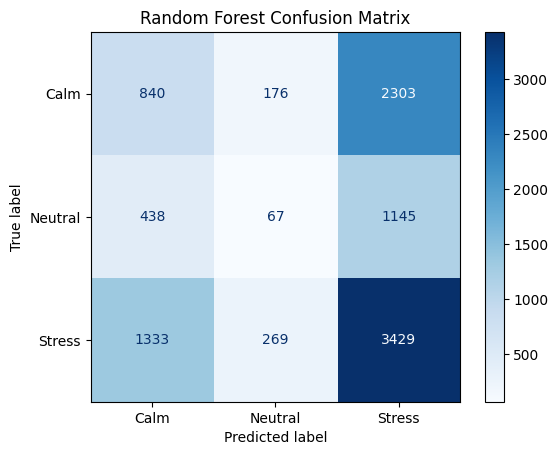

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,Keystroke_Latency_ms,0.208564
4,Stress_Index,0.207906
1,Handwriting_Pressure_kPa,0.204644
3,Audio_Keystroke_Interaction,0.201381
0,Audio_Jitter_ms,0.177505


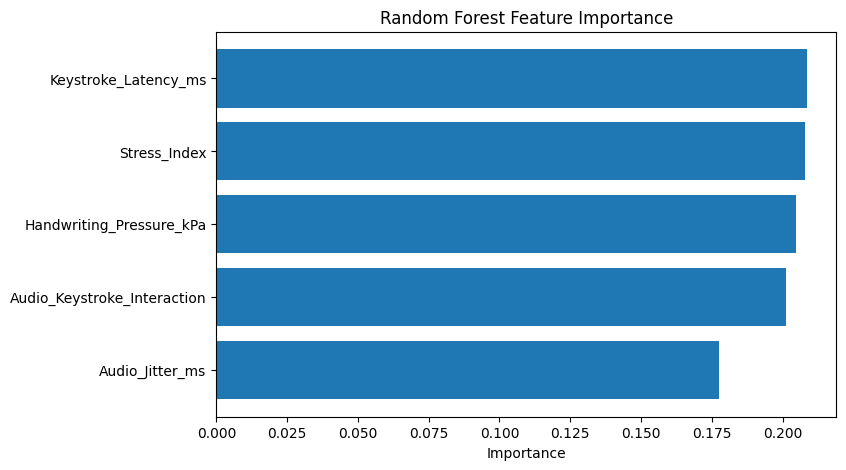

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.xlabel("Importance")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
print("Random Forest Performance")

print("--------------------------")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC AUC  : {roc:.4f}")

Random Forest Performance
--------------------------
Accuracy : 0.4336
Precision: 0.3171
Recall   : 0.3251
F1 Score : 0.3071
ROC AUC  : 0.5023


SVM

In [ ]:
svm = SVC(

    kernel="rbf",

    C=1.0,

    gamma="scale",

    probability=True,

    class_weight="balanced",

    random_state=42

)

In [ ]:
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

y_prob = svm.predict_proba(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

roc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro"
)

In [ ]:
print("Classification Report - Support Vector Machine")
print("---------------------------------------------")

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

Classification Report - Support Vector Machine
---------------------------------------------
              precision    recall  f1-score   support

        Calm       0.35      0.31      0.33      3319
     Neutral       0.17      0.43      0.24      1650
      Stress       0.51      0.28      0.36      5031

    accuracy                           0.31     10000
   macro avg       0.34      0.34      0.31     10000
weighted avg       0.40      0.31      0.33     10000



In [ ]:
svm_results = {
    "Model": "Support Vector Machine",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc
}

In [ ]:
print("="*50)
print("Support Vector Machine Performance Summary")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")

print("="*50)

Support Vector Machine Performance Summary
Accuracy  : 0.3148
Precision : 0.3403
Recall    : 0.3401
F1-Score  : 0.3095
ROC-AUC   : 0.4937


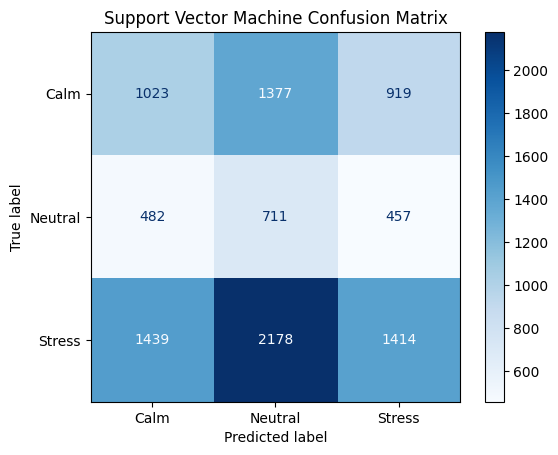

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Support Vector Machine Confusion Matrix")

plt.show()

MLP

In [ ]:
mlp = Sequential([

    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.20),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.20),

    Dense(16, activation='relu'),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=5,

    verbose=1
)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

history = mlp.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,  # ← add this
    verbose=1
)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3322 - loss: 1.1292 - val_accuracy: 0.4159 - val_loss: 1.0837 - learning_rate: 0.0010
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3397 - loss: 1.1025 - val_accuracy: 0.3692 - val_loss: 1.0935 - learning_rate: 0.0010
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3343 - loss: 1.1007 - val_accuracy: 0.3905 - val_loss: 1.0945 - learning_rate: 0.0010
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3424 - loss: 1.0988 - val_accuracy: 0.3314 - val_loss: 1.1000 - learning_rate: 0.0010
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3284 - loss: 1.0987 - val_accuracy: 0.4178 - val_loss: 1.0926 - learning_rate: 0.0010
Epoch 6/100
 995/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3383 - loss: 1.0985
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.346

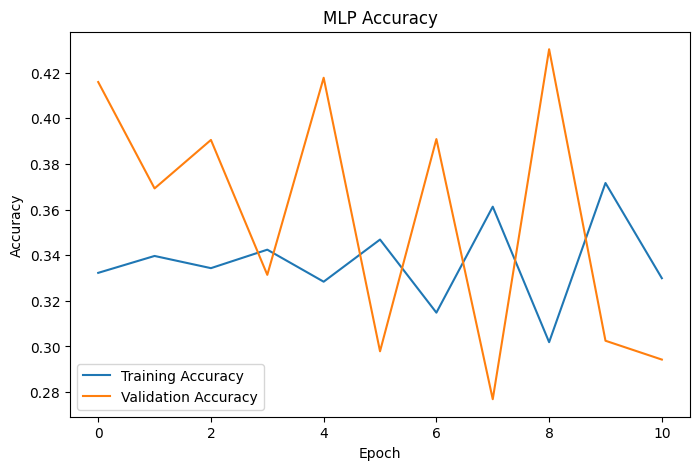

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("MLP Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

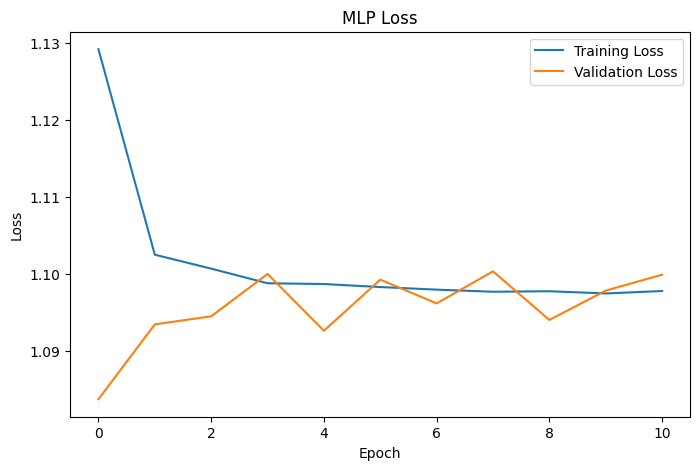

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("MLP Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
y_prob = mlp.predict(X_test_scaled)

y_pred = y_prob.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4091


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average='macro'
)

print("Precision:", precision)

Precision: 0.33217998555169376


In [ ]:
recall = recall_score(
    y_test,
    y_pred,
    average='macro'
)

print("Recall:", recall)

Recall: 0.3326086643029964


In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("F1 Score:", f1)

F1 Score: 0.33050114420950294


In [ ]:
roc = roc_auc_score(

    y_test,

    y_prob,

    multi_class='ovr',

    average='macro'

)

print("ROC-AUC:", roc)

ROC-AUC: 0.4983529943396565


In [ ]:
print("Classification Report - Multi-Layer Perceptron")
print("----------------------------------------------")

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

Classification Report - Multi-Layer Perceptron
----------------------------------------------
              precision    recall  f1-score   support

        Calm       0.34      0.29      0.31      3319
     Neutral       0.15      0.13      0.14      1650
      Stress       0.51      0.58      0.54      5031

    accuracy                           0.41     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.39      0.41      0.40     10000



In [ ]:
mlp_results = {
    "Model": "Multi-Layer Perceptron",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "ROC-AUC": roc
}

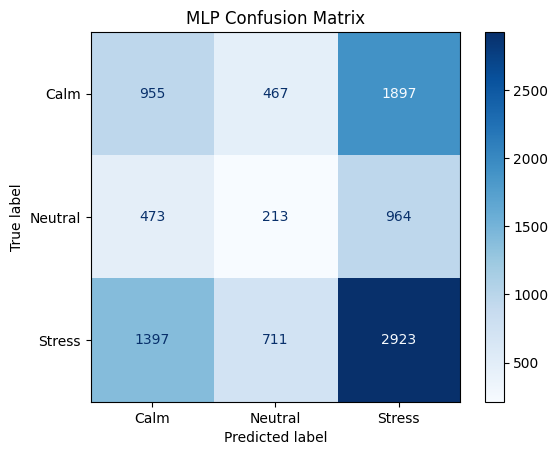

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("MLP Confusion Matrix")

plt.show()

In [ ]:
print("="*50)
print("Multi-Layer Perceptron Performance Summary")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")

print("="*50)

Multi-Layer Perceptron Performance Summary
Accuracy  : 0.4091
Precision : 0.3322
Recall    : 0.3326
F1-Score  : 0.3305
ROC-AUC   : 0.4984


Comparison

In [ ]:
comparison = pd.DataFrame([
    rf_results,
    svm_results,
    mlp_results
])

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.4336,0.317065,0.325090,0.307067,0.502254
1,Support Vector Machine,0.3148,0.340321,0.340064,0.309545,0.493681
2,Multi-Layer Perceptron,0.4091,0.332180,0.332609,0.330501,0.498353


In [ ]:
comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.4336,0.3171,0.3251,0.3071,0.5023
1,Support Vector Machine,0.3148,0.3403,0.3401,0.3095,0.4937
2,Multi-Layer Perceptron,0.4091,0.3322,0.3326,0.3305,0.4984


In [ ]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model        Random Forest
Accuracy            0.4336
Precision           0.3171
Recall              0.3251
F1-Score            0.3071
ROC-AUC             0.5023
Name: 0, dtype: object


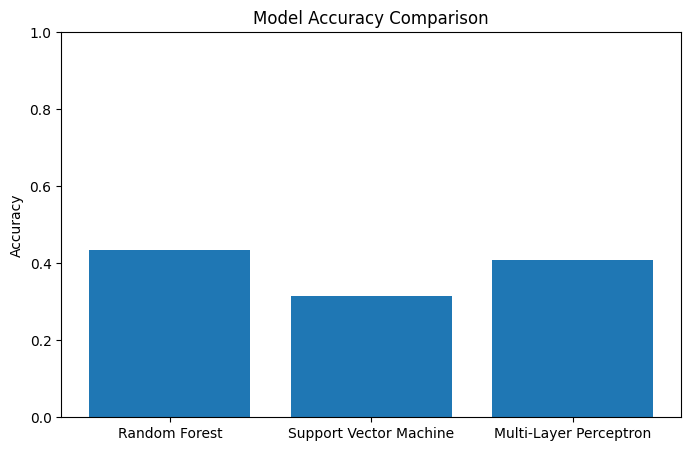

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

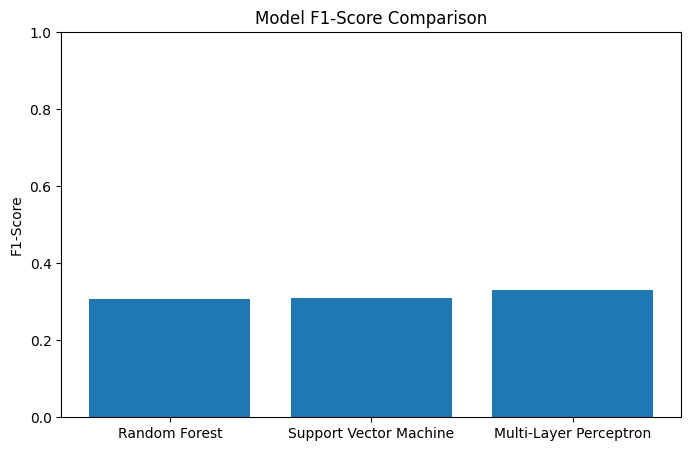

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1-Score"]
)

plt.title("Model F1-Score Comparison")

plt.ylabel("F1-Score")

plt.ylim(0,1)

plt.show()

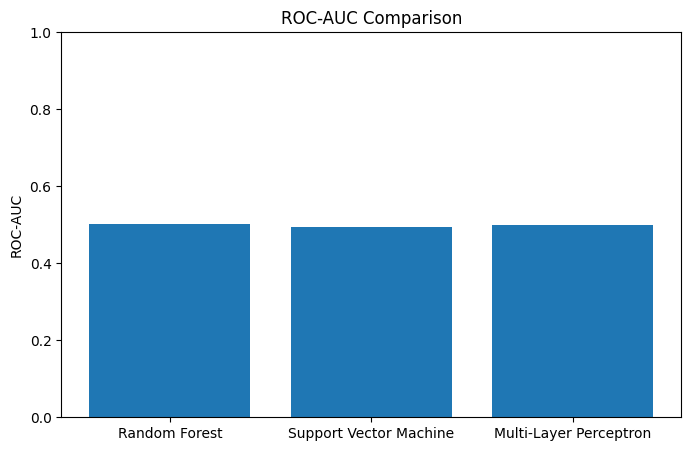

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.title("ROC-AUC Comparison")

plt.ylabel("ROC-AUC")

plt.ylim(0,1)

plt.show()

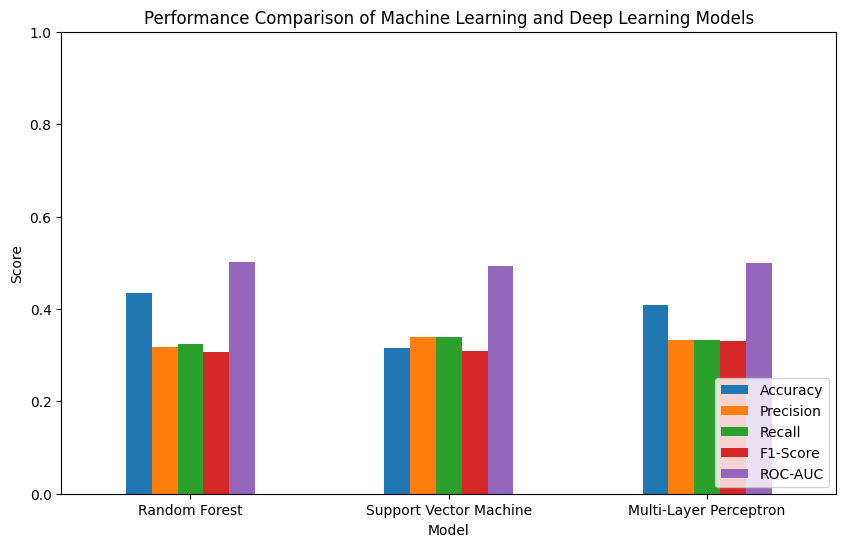

In [ ]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of Machine Learning and Deep Learning Models")

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.show()

In [ ]:
print("="*70)
print("Overall Model Comparison")
print("="*70)

print(comparison)

print("\nBest Model Based on Accuracy:")

print(best_model["Model"])

print("="*70)

Overall Model Comparison
                    Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0           Random Forest    0.4336     0.3171  0.3251    0.3071   0.5023
1  Support Vector Machine    0.3148     0.3403  0.3401    0.3095   0.4937
2  Multi-Layer Perceptron    0.4091     0.3322  0.3326    0.3305   0.4984

Best Model Based on Accuracy:
Random Forest
